# Explorasi Data

## Import Library yang Diperlukan
Import semua library yang dibutuhkan. pandas untuk data, psycopg2 untuk DB, numpy dan scipy untuk stats, matplotlib untuk plot. Tambahkan !pip install ... jika library belum ada.

In [ ]:
%pip install pandas sqlalchemy psycopg2-binary python-dotenv numpy

In [ ]:
import pandas as pd
import psycopg2
from psycopg2 import sql
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

## Load Dataset dari CSV dan Preview Awal
Load file data.csv ke DataFrame pandas. Kemudian, tampilkan preview (5 baris pertama) dan info (tipe data, jumlah baris). Ini membantu memahami struktur data sebelum cleaning. Jika file tidak ada, error akan muncul pastikan file disimpan di folder yang sama.

In [ ]:
# Load CSV ke DataFrame
df = pd.read_csv("./dataset/retail_data.csv")

# Preview data
print("Preview Data:")
print(df.head())

# Info data awal (tipe data, non-null count)
print("\nInfo Data Awal:")
print(df.info())

Preview Data:
  Order No  Order Date           Customer Name  \
0   4293-1  02-09-2014        Vivek Sundaresam   
1   5001-1  24-10-2015          Shahid Hopkins   
2   5004-1  13-03-2014           Dennis Pardue   
3   5009-1  18-02-2013              Sean Wendt   
4   5010-1  13-09-2014  Christina Vanderzanden   

                          Address       City State   Customer Type  \
0  152 Bunnerong Road,Eastgardens     Sydney   NSW  Small Business   
1   438 Victoria Avenue,Chatswood     Sydney   NSW       Corporate   
2        412 Brunswick St,Fitzroy  Melbourne   VIC        Consumer   
3        145 Ramsay St,Haberfield     Sydney   NSW  Small Business   
4          188 Pitt Street,Sydney     Sydney   NSW  Small Business   

  Account Manager Order Priority  \
0    Tina Carlton       Critical   
1    Natasha Song         Medium   
2    Connor Betts  Not Specified   
3     Phoebe Gour       Critical   
4    Tina Carlton  Not Specified   

                                     Product Na

## Bersihkan Kolom Numerik dan Konversi Tanggal
Kolom seperti 'Sub Total' punya simbol '$' dan ',', jadi kita hilangkan dan ubah ke float agar bisa dihitung. Juga konversi kolom tanggal ke format datetime. Ini penting untuk EDA nanti (misalnya hitung IQR atau cek konsistensi tanggal). Jika kolom tidak ada atau sudah bersih, kode tetap aman.

In [ ]:
# Kolom yang perlu dibersihkan (hilangkan '$' dan ',')
cols_to_clean = ["Sub Total", "Discount $", "Order Total", "Total"]
for col in cols_to_clean:
    if col in df.columns:
        df[col] = (
            df[col]
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .astype(float)
        )

# Konversi tanggal ke datetime (format DD-MM-YYYY)
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y", errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d-%m-%Y", errors="coerce")

# Preview setelah cleaning
print("\nInfo Data Setelah Cleaning:")
print(df.info())


Info Data Setelah Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Order No           5000 non-null   object        
 1   Order Date         5000 non-null   datetime64[ns]
 2   Customer Name      5000 non-null   object        
 3   Address            4999 non-null   object        
 4   City               5000 non-null   object        
 5   State              5000 non-null   object        
 6   Customer Type      5000 non-null   object        
 7   Account Manager    5000 non-null   object        
 8   Order Priority     5000 non-null   object        
 9   Product Name       5000 non-null   object        
 10  Product Category   5000 non-null   object        
 11  Product Container  5000 non-null   object        
 12  Ship Mode          5000 non-null   object        
 13  Ship Date          5000 non-null  

## Setup Database PostgreSQL
Definisikan variabel untuk koneksi DB. Ganti nilai seperti username, password dengan kredential yang benar. Ini memudahkan jika perlu ubah.

In [ ]:
import os
from dotenv import load_dotenv

load_dotenv()

PG_HOST = os.getenv("PG_HOST", "localhost")
PG_PORT = os.getenv("PG_PORT", "5432")
PG_USER = os.getenv("PG_USER", "username")
PG_PASSWORD = os.getenv("PG_PASSWORD", "password")
PG_DB = os.getenv("PG_DB", "database_name")
PG_SCHEMA = os.getenv("PG_SCHEMA", "public")

## Buat Database Baru di PostgreSQL
Koneksi ke DB default ('postgres') untuk buat database baru (psd). Jika sudah ada, skip dengan pesan. Ini langkah awal setup DB. Jalankan sekali saja.

In [ ]:
# Koneksi ke default DB untuk buat database baru
conn = psycopg2.connect(
    dbname="postgres", user=PG_USER, password=PG_PASSWORD, host=PG_HOST, port=PG_PORT
)
conn.autocommit = True
cur = conn.cursor()

# Buat database
try:
    cur.execute(sql.SQL("CREATE DATABASE {}").format(sql.Identifier(PG_DB)))
    print(f"Database {PG_DB} created successfully.")
except psycopg2.errors.DuplicateDatabase:
    print(f"Database {PG_DB} already exists.")

cur.close()
conn.close()

Database psd_db already exists.


## Buat Table di Database dan Insert Data
Koneksi ke DB baru, buat table retail_data dengan struktur sesuai kolom CSV. Kemudian, insert data menggunakan to_sql (lebih efisien daripada loop). Gunakan sqlalchemy untuk ini install jika belum (!pip install sqlalchemy). Verifikasi dengan query SELECT 5 baris pertama.

In [ ]:
# Install sqlalchemy jika belum (jalankan di Colab: !pip install sqlalchemy)
from sqlalchemy import create_engine
import time

# Koneksi ke DB baru
conn = psycopg2.connect(
    dbname=PG_DB, user=PG_USER, password=PG_PASSWORD, host=PG_HOST, port=PG_PORT
)
cur = conn.cursor()

# Query buat table
create_table_query = """
CREATE TABLE IF NOT EXISTS retail_data (
    order_no VARCHAR(50),
    order_date DATE,
    customer_name VARCHAR(100),
    address VARCHAR(200),
    city VARCHAR(50),
    state VARCHAR(50),
    customer_type VARCHAR(50),
    account_manager VARCHAR(100),
    order_priority VARCHAR(50),
    product_name VARCHAR(200),
    product_category VARCHAR(50),
    product_container VARCHAR(50),
    ship_mode VARCHAR(50),
    ship_date DATE,
    cost_price FLOAT,
    retail_price FLOAT,
    profit_margin FLOAT,
    order_quantity INTEGER,
    sub_total FLOAT,
    discount_percent FLOAT,
    discount_dollar FLOAT,
    order_total FLOAT,
    shipping_cost FLOAT,
    total FLOAT
);
"""
cur.execute(create_table_query)
print("Table 'retail_data' created successfully.")

# Insert data menggunakan to_sql dengan chunksize agar lebih cepat
engine = create_engine(
    f"postgresql://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}"
)
df.to_sql("retail_data", engine, if_exists="replace", index=False)

# Verifikasi: Query sample data
cur.execute("SELECT * FROM retail_data LIMIT 5;")
rows = cur.fetchall()
print("\nSample Data from DB:")
for row in rows:
    print(row)

Table 'retail_data' created successfully.

Sample Data from DB:
('4293-1', datetime.datetime(2014, 9, 2, 0, 0), 'Vivek Sundaresam', '152 Bunnerong Road,Eastgardens', 'Sydney', 'NSW', 'Small Business', 'Tina Carlton', 'Critical', 'UGen Ultra Professional Cordless Optical Suite', 'Office Supplies', 'Small Box', 'Regular Air', datetime.datetime(2014, 9, 4, 0, 0), '$156.50', '$300.97', '$144.47', 23.0, 4533.52, '2%', 194.83, 4757.22, '$7.18', 4291.55)
('5001-1', datetime.datetime(2015, 10, 24, 0, 0), 'Shahid Hopkins', '438 Victoria Avenue,Chatswood', 'Sydney', 'NSW', 'Corporate', 'Natasha Song', 'Medium', 'Bagged Rubber Bands', 'Office Supplies', 'Small Pack', 'Regular Air', datetime.datetime(2015, 10, 26, 0, 0), '$0.24', '$1.26', '$1.02', 8.0, 45.2, '3%', 0.0, 45.9, '$0.70', 46.91)
('5004-1', datetime.datetime(2014, 3, 13, 0, 0), 'Dennis Pardue', '412 Brunswick St,Fitzroy', 'Melbourne', 'VIC', 'Consumer', 'Connor Betts', 'Not Specified', 'TechSavi Cordless Navigator Duo', 'Office Supplies

## EDA - Tipe Data dan Missing Values
Mulai EDA. Tampilkan tipe data. Hitung dan tampilkan missing values per kolom. Tangani missing dengan isi mean untuk kolom numerik (bisa diganti strategi lain jika perlu).

In [ ]:
# a. Tipe Data
print("\nTipe Data Kolom:")
print(df.dtypes)


Tipe Data Kolom:
Order No                     object
Order Date           datetime64[ns]
Customer Name                object
Address                      object
City                         object
State                        object
Customer Type                object
Account Manager              object
Order Priority               object
Product Name                 object
Product Category             object
Product Container            object
Ship Mode                    object
Ship Date            datetime64[ns]
Cost Price                   object
Retail Price                 object
Profit Margin                object
Order Quantity              float64
Sub Total                   float64
Discount %                   object
Discount $                  float64
Order Total                 float64
Shipping Cost                object
Total                       float64
dtype: object


In [ ]:
# b. Kualitas Data - Missing Values
print("\nMissing Values per Kolom:")
missing = df.isnull().sum()
print(missing)


Missing Values per Kolom:
Order No             0
Order Date           0
Customer Name        0
Address              1
City                 0
State                0
Customer Type        0
Account Manager      0
Order Priority       0
Product Name         0
Product Category     0
Product Container    0
Ship Mode            0
Ship Date            0
Cost Price           0
Retail Price         0
Profit Margin        0
Order Quantity       0
Sub Total            0
Discount %           0
Discount $           0
Order Total          0
Shipping Cost        0
Total                0
dtype: int64


In [ ]:
# Tangani missing (isi dengan mean untuk numerik)
df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)
print("\nMissing Values setelah Handling:")
print(df.isnull().sum())


Missing Values setelah Handling:
Order No             0
Order Date           0
Customer Name        0
Address              1
City                 0
State                0
Customer Type        0
Account Manager      0
Order Priority       0
Product Name         0
Product Category     0
Product Container    0
Ship Mode            0
Ship Date            0
Cost Price           0
Retail Price         0
Profit Margin        0
Order Quantity       0
Sub Total            0
Discount %           0
Discount $           0
Order Total          0
Shipping Cost        0
Total                0
dtype: int64


## EDA - Outlier Analisis dengan IQR
Hitung outlier menggunakan metode IQR untuk kolom numerik penting. Tampilkan jumlah outlier dan contohnya. Ini sesuai tugas (outlier analysis IQR).

In [ ]:
# - Outlier Analisis (IQR)
print("Kolom yang tersedia:")
print(df.columns.tolist())

# Gunakan nama kolom yang sesuai dengan data yang dimuat
numeric_cols = []
# Cek kolom numerik yang ada
for col in df.select_dtypes(include=[np.number]).columns:
    numeric_cols.append(col)

print(f"\nKolom numerik yang ditemukan: {numeric_cols}")

outliers_dict = {}
for col in numeric_cols:
    if col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outliers_dict[col] = len(outliers)
        print(f"\nOutliers di {col} (IQR method): {len(outliers)}")
        if not outliers.empty and len(outliers) > 0:
            print(f"Contoh nilai outliers: {outliers[col].head().tolist()}")
            print(f"Batas bawah: {lower_bound:.2f}, Batas atas: {upper_bound:.2f}")

Kolom yang tersedia:
['Order No', 'Order Date', 'Customer Name', 'Address', 'City', 'State', 'Customer Type', 'Account Manager', 'Order Priority', 'Product Name', 'Product Category', 'Product Container', 'Ship Mode', 'Ship Date', 'Cost Price', 'Retail Price', 'Profit Margin', 'Order Quantity', 'Sub Total', 'Discount %', 'Discount $', 'Order Total', 'Shipping Cost', 'Total']

Kolom numerik yang ditemukan: ['Order Quantity', 'Sub Total', 'Discount $', 'Order Total', 'Total']

Outliers di Order Quantity (IQR method): 0

Outliers di Sub Total (IQR method): 682
Contoh nilai outliers: [4533.52, 1079.62, 1602.02, 1029.5, 5213.76]
Batas bawah: -483.75, Batas atas: 979.85

Outliers di Discount $ (IQR method): 712
Contoh nilai outliers: [194.83, 72.23, 144.41, 58.07, 58.07]
Batas bawah: -22.70, Batas atas: 43.79

Outliers di Order Total (IQR method): 697
Contoh nilai outliers: [4757.22, 1753.33, 1513.83, 1762.54, 4744.52]
Batas bawah: -460.24, Batas atas: 932.91

Outliers di Total (IQR method): 

## EDA - Konsistensi Data dan Duplikat
Cek duplikat dan hapus. Cek konsistensi profit margin (hitung ulang dan bandingkan). Cek logis tanggal (ship date >= order date). Ini untuk memeriksa "konsistensi data (bagaimana terkait dengan keberadaan?)" seperti di tugas.

In [ ]:
def outlier_iqr(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper


num_cols = ["Sales", "Quantity", "Discount", "Profit"]
for col in num_cols:
    if col in df.columns:
        lo, hi = outlier_iqr(df[col])
        n_out = ((df[col] < lo) | (df[col] > hi)).sum()
        print(f"{col}: {n_out} outlier(s), batas bawah={lo}, batas atas={hi}")

## EDA - Statistik Deskriptif dan Visualisasi
Tampilkan statistik seperti mean, min, max. Buat histogram untuk distribusi (contoh: Profit Margin). Ini bagian "dll" untuk kualitas data.


Statistik Deskriptif:
                       Order Date                      Ship Date  \
count                        5000                           5000   
mean   2015-02-03 19:21:30.240000  2015-02-05 15:24:46.079999744   
min           2013-02-11 00:00:00            2013-02-12 00:00:00   
25%           2014-01-10 00:00:00            2014-01-11 00:00:00   
50%           2015-02-04 00:00:00            2015-02-10 00:00:00   
75%           2016-02-10 00:00:00            2016-02-11 00:00:00   
max           2017-02-07 00:00:00            2017-02-07 00:00:00   
std                           NaN                            NaN   

       Order Quantity     Sub Total  Discount $   Order Total        Total  
count     5000.000000   5000.000000   5000.0000   5000.000000   5000.00000  
mean        26.483097    783.586770     49.4329    761.799970    746.30728  
min          1.000000      1.880000      0.0000      1.710000      2.85000  
25%         13.000000     65.100000      2.2375     62.1

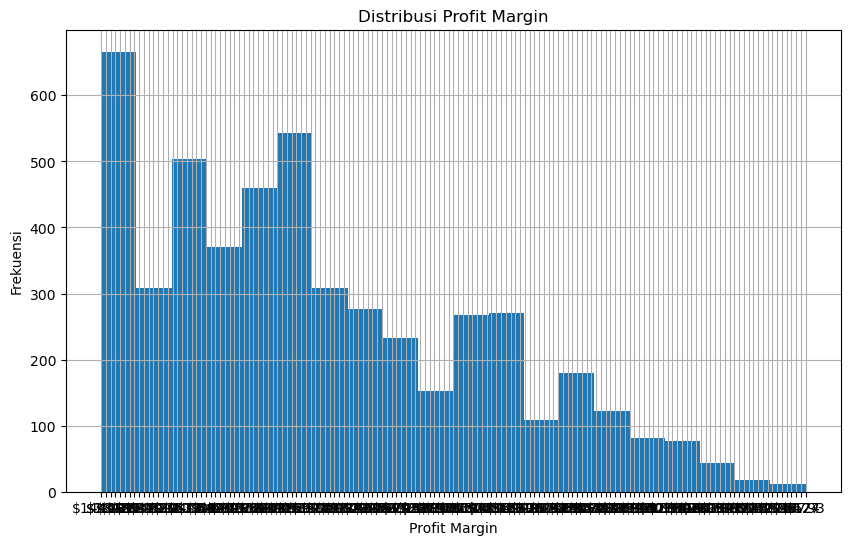

In [ ]:
# - Lainnya: Statistik Deskriptif
print("\nStatistik Deskriptif:")
print(df.describe())

# Visualisasi distribusi (histogram Profit Margin)
plt.figure(figsize=(10, 6))
df["Profit Margin"].hist(bins=20)
plt.title("Distribusi Profit Margin")
plt.xlabel("Profit Margin")
plt.ylabel("Frekuensi")
plt.show()